In [53]:
print("Jai Shree Krishna.")

Jai Shree Krishna.


In [54]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

### Linear Regression 

In [55]:
data = pd.read_excel("Creep_data_750K.xlsx")

In [56]:
data.head()

,Stress,Time,Temperature,Strain
0,6.93,0.0,750,1.954672e-16
1,6.93,0.2,750,3.019095e-02
2,6.93,0.4,750,4.881192e-02
3,6.93,0.6,750,6.169802e-02
4,6.93,0.8,750,6.896040e-02


In [57]:
x =  data["Time"].values.reshape(-1,1)
y =  data["Strain"].values

In [58]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [59]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred =  model.predict(x_test)

In [61]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r_square =  r2_score(y_test, y_pred)

In [62]:
print("Mean Squared Error:", mse)
print("R Squared Error:", r_square)

Mean Squared Error: 4.255655818846765
R Squared Error: 0.003948690425553458


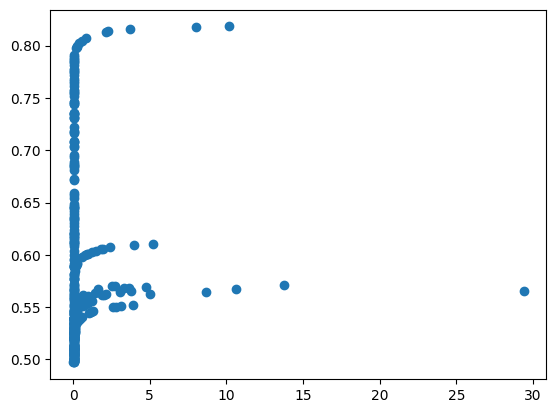

In [63]:
plt.scatter(y_test, y_pred)
plt.show()

### Polynomial Regression

In [64]:
a = data.iloc[:, :-1].values
b = data["Strain"].values

In [65]:
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=42, shuffle=True)

In [66]:
from sklearn.preprocessing import PolynomialFeatures

PR =  PolynomialFeatures(degree=2)
a_pr_train = PR.fit_transform(a_train)
a_pr_test  = PR.fit_transform(a_test)

In [67]:
model.fit(a_pr_train, b_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
b_pred = model.predict(a_pr_test)

In [69]:
mse = mean_squared_error(b_test, b_pred)
r_square =  r2_score(b_test, b_pred)
print("Mean Squared Error:", mse)
print("R Squared Error:", r_square)

Mean Squared Error: 3.727264183996305
R Squared Error: 0.1276206230875342


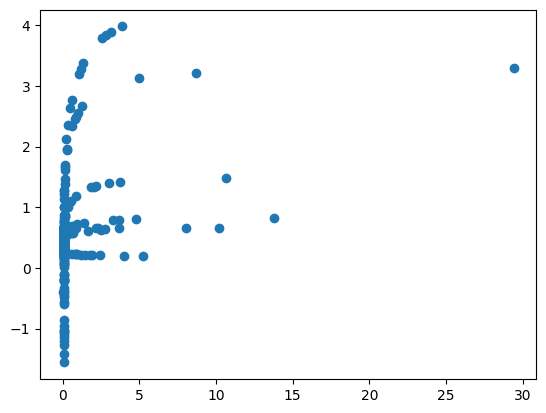

In [91]:
plt.scatter(b_test, b_pred)
plt.show()

### Random forest Regression 

In [70]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=100, random_state=0)
rfr.fit(a_train, b_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
rf_pred = rfr.predict(a_test)

In [72]:
mse = mean_squared_error(b_test, rf_pred)
r_square =  r2_score(b_test, rf_pred)
print("Mean Squared Error:", mse)
print("R Squared Error:", r_square)

Mean Squared Error: 0.8156993893515064
R Squared Error: 0.8090826703173527


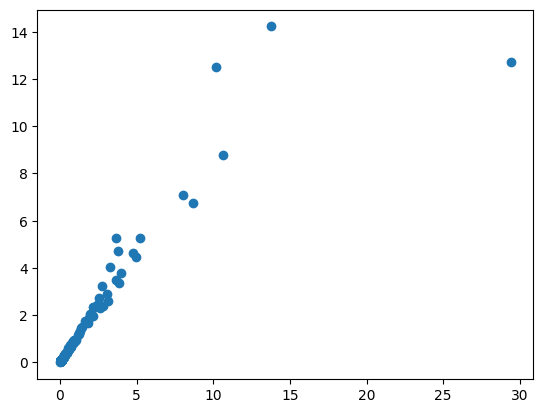

In [92]:
plt.scatter(b_test, rf_pred)
plt.show()

### XGboost 

In [88]:
from xgboost import XGBRegressor 
xgr =  XGBRegressor(n_estimators=100,
                    learning_rate=0.1)
xgr.fit(a_train, b_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [89]:
xgr_pred = xgr.predict(a_test)

In [90]:
mse = mean_squared_error(b_test, xgr_pred)
r_square =  r2_score(b_test, xgr_pred)
print("Mean Squared Error:", mse)
print("R Squared Error:", r_square)

Mean Squared Error: 1.0423350675289746
R Squared Error: 0.7560377875415334


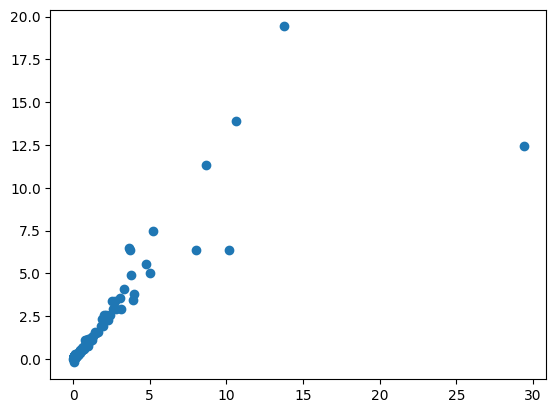

In [93]:
plt.scatter(b_test, xgr_pred)
plt.show()